In [1]:
import os
import cv2
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("✅ همه کتابخانه‌ها با موفقیت بارگذاری شدند")

✅ همه کتابخانه‌ها با موفقیت بارگذاری شدند


In [ ]:
original_dataset = r'D:\plant-classifier-project01\datasets\PlantVillage\PlantVillage'
balanced_dataset = r'D:\plant-classifier-project01\datasets_balanced'

TOTAL_IMAGES = 16000
IMG_SIZE = 128
VALID_EXT = ['.jpg', '.jpeg', '.png']

print(f"📁 مسیر دیتاست: {original_dataset}")
print(f"🖼️  سایز تصاویر: {IMG_SIZE}×{IMG_SIZE}")
print(f"📊 تعداد کل تصاویر هدف: {TOTAL_IMAGES}")

📁 مسیر دیتاست: D:\plant-classifier-project01\datasets\PlantVillage
🖼️  سایز تصاویر: 128×128
📊 تعداد کل تصاویر هدف: 16000


In [ ]:
classes = sorted([
    d for d in os.listdir(original_dataset)
    if os.path.isdir(os.path.join(original_dataset, d))
])

num_classes = len(classes)
per_class = TOTAL_IMAGES // num_classes

print(f"🌿 تعداد کلاس‌ها: {num_classes}")
print(f"📸 تصاویر برای هر کلاس: {per_class}")

for i, cls in enumerate(classes, 1):
    print(f"   {i}. {cls}") 

🌿 تعداد کلاس‌ها: 16
📸 تصاویر برای هر کلاس: 1000
   1. Pepper__bell___Bacterial_spot
   2. Pepper__bell___healthy
   3. PlantVillage
   4. Potato___Early_blight
   5. Potato___Late_blight
   6. Potato___healthy
   7. Tomato_Bacterial_spot
   8. Tomato_Early_blight
   9. Tomato_Late_blight
   10. Tomato_Leaf_Mold
   11. Tomato_Septoria_leaf_spot
   12. Tomato_Spider_mites_Two_spotted_spider_mite
   13. Tomato__Target_Spot
   14. Tomato__Tomato_YellowLeaf__Curl_Virus
   15. Tomato__Tomato_mosaic_virus
   16. Tomato_healthy


In [4]:
if os.path.exists(balanced_dataset):
    print("⚠️ حذف دیتاست قبلی...")
    shutil.rmtree(balanced_dataset)

os.makedirs(balanced_dataset, exist_ok=True)

print("🔄 در حال ساخت دیتاست متوازن...")

for cls in classes:
    src = os.path.join(original_dataset, cls)
    dst = os.path.join(balanced_dataset, cls)
    os.makedirs(dst, exist_ok=True)
    
    images = [f for f in os.listdir(src) if os.path.splitext(f)[1].lower() in VALID_EXT]
    random.shuffle(images)
    
    for img in images[:per_class]:
        shutil.copy(os.path.join(src, img), os.path.join(dst, img))
    
    print(f"   ✅ {cls}: {len(images[:per_class])} تصویر")

print("✅ دیتاست متوازن ساخته شد")

⚠️ حذف دیتاست قبلی...
🔄 در حال ساخت دیتاست متوازن...
   ✅ Pepper__bell___Bacterial_spot: 997 تصویر
   ✅ Pepper__bell___healthy: 1000 تصویر
   ✅ PlantVillage: 0 تصویر
   ✅ Potato___Early_blight: 1000 تصویر
   ✅ Potato___Late_blight: 1000 تصویر
   ✅ Potato___healthy: 152 تصویر
   ✅ Tomato_Bacterial_spot: 1000 تصویر
   ✅ Tomato_Early_blight: 1000 تصویر
   ✅ Tomato_Late_blight: 1000 تصویر
   ✅ Tomato_Leaf_Mold: 952 تصویر
   ✅ Tomato_Septoria_leaf_spot: 1000 تصویر
   ✅ Tomato_Spider_mites_Two_spotted_spider_mite: 1000 تصویر
   ✅ Tomato__Target_Spot: 1000 تصویر
   ✅ Tomato__Tomato_YellowLeaf__Curl_Virus: 1000 تصویر
   ✅ Tomato__Tomato_mosaic_virus: 373 تصویر
   ✅ Tomato_healthy: 1000 تصویر
✅ دیتاست متوازن ساخته شد


In [5]:
data, labels = [], []

for label, cls in enumerate(classes):
    folder = os.path.join(balanced_dataset, cls)
    for img_name in os.listdir(folder):
        if os.path.splitext(img_name)[1].lower() in VALID_EXT:
            img = cv2.imread(os.path.join(folder, img_name))
            if img is not None:
                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0
                data.append(img)
                labels.append(label)

X = np.array(data)
y = np.array(labels)

print(f"📊 شکل داده‌ها: {X.shape}")
print(f"📊 شکل برچسب‌ها: {y.shape}")

📊 شکل داده‌ها: (13474, 128, 128, 3)
📊 شکل برچسب‌ها: (13474,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"📚 آموزش: {len(X_train)} تصویر")
print(f"📖 تست: {len(X_test)} تصویر")

📚 آموزش: 10779 تصویر
📖 تست: 2695 تصویر


In [7]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ مدل CNN ساخته شد")
cnn_model.summary()

C:\Users\Lenovo\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ مدل CNN ساخته شد


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,306,704 (12.61 MB)

 Trainable params: 3,306,704 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
print("🚀 شروع آموزش CNN...")

cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    verbose=1
)

print("✅ آموزش CNN تمام شد")

🚀 شروع آموزش CNN...
Epoch 1/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 208s 604ms/step - accuracy: 0.2031 - loss: 2.3849 - val_accuracy: 0.6482 - val_loss: 1.2346
Epoch 2/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 200s 594ms/step - accuracy: 0.5170 - loss: 1.4396 - val_accuracy: 0.7607 - val_loss: 0.8008
Epoch 3/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 201s 596ms/step - accuracy: 0.6318 - loss: 1.1113 - val_accuracy: 0.7974 - val_loss: 0.6243
Epoch 4/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 206s 609ms/step - accuracy: 0.6950 - loss: 0.9092 - val_accuracy: 0.8341 - val_loss: 0.5248
Epoch 5/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 202s 598ms/step - accuracy: 0.7442 - loss: 0.7394 - val_accuracy: 0.8616 - val_loss: 0.4496
Epoch 6/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 209s 619ms/step - accuracy: 0.7708 - loss: 0.6787 - val_accuracy: 0.8801 - val_loss: 0.3800
Epoch 7/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 202s 602ms/step - accuracy: 0.8017 - loss: 0.5736 - val_accuracy: 0.8612 - val_loss: 0.4326
Epoch 8/15
337/337 ━━━━━━━━━━━━━━━━━━━━ 211s 626ms/step 

In [9]:
cnn_model.save('plant_cnn_model.h5')
print("💾 مدل CNN ذخیره شد: plant_cnn_model.h5")

💾 مدل CNN ذخیره شد: plant_cnn_model.h5


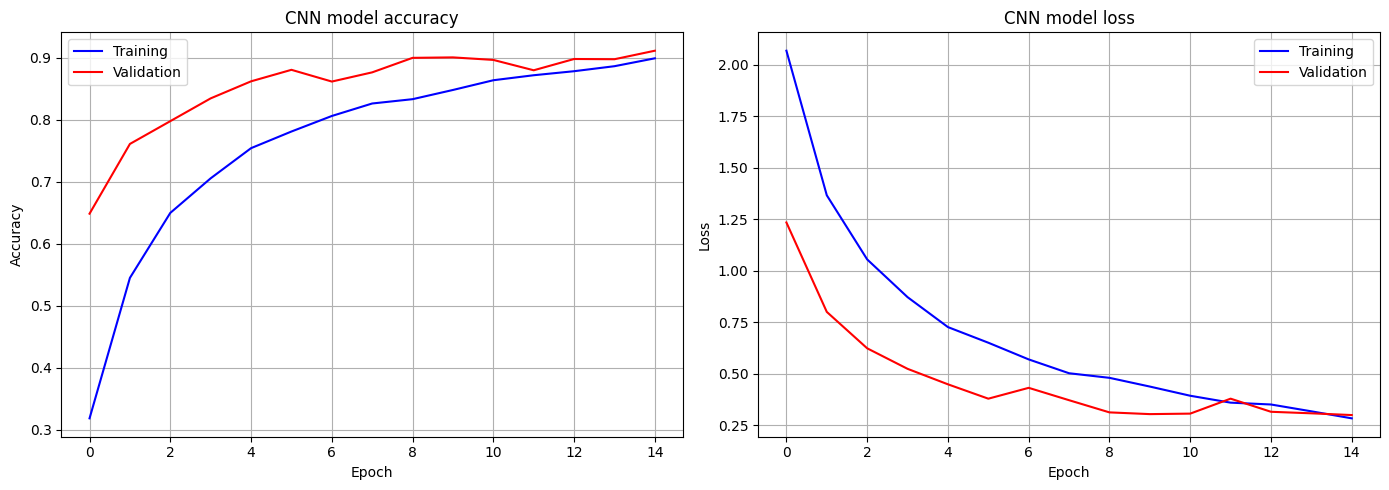

In [10]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], 'b-', label='Training')
plt.plot(cnn_history.history['val_accuracy'], 'r-', label='Validation')
plt.title('CNN model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], 'b-', label='Training')
plt.plot(cnn_history.history['val_loss'], 'r-', label='Validation')
plt.title('CNN model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# محاسبه معیارهای ارزیابی CNN روی داده‌های تست
y_pred_cnn = np.argmax(cnn_model.predict(X_test), axis=1)

acc_cnn = accuracy_score(y_test, y_pred_cnn) * 100
pre_cnn = precision_score(y_test, y_pred_cnn, average='macro', zero_division=0) * 100
rec_cnn = recall_score(y_test, y_pred_cnn, average='macro', zero_division=0) * 100
f1_cnn = f1_score(y_test, y_pred_cnn, average='macro', zero_division=0) * 100

print("✅ معیارهای CNN محاسبه شد:")
print(f"   Accuracy:  {acc_cnn:.2f}%")
print(f"   Precision: {pre_cnn:.2f}%")
print(f"   Recall:    {rec_cnn:.2f}%")
print(f"   F1-Score:  {f1_cnn:.2f}%")

85/85 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step
✅ معیارهای CNN محاسبه شد:
   Accuracy:  91.09%
   Precision: 91.22%
   Recall:    90.57%
   F1-Score:  90.73%


In [12]:
print("="*50)
print("🔹 ارزیابی مدل CNN")
print("="*50)
print(f"دقت (Accuracy):  {acc_cnn:.2f}%")
print(f"دقت (Precision): {pre_cnn:.2f}%")
print(f"حساسیت (Recall): {rec_cnn:.2f}%")
print(f"F1-Score:        {f1_cnn:.2f}%")

print("\n📋 گزارش کامل (فقط کلاس‌های دارای داده):")

# پیدا کردن کلاس‌هایی که در y_test وجود دارند
unique_labels = np.unique(y_test)
filtered_class_names = [classes[i] for i in unique_labels]

print(classification_report(
    y_test, y_pred_cnn,
    labels=unique_labels,
    target_names=filtered_class_names,
    zero_division=0
))

🔹 ارزیابی مدل CNN
دقت (Accuracy):  91.09%
دقت (Precision): 91.22%
حساسیت (Recall): 90.57%
F1-Score:        90.73%

📋 گزارش کامل (فقط کلاس‌های دارای داده):
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.95      0.86      0.91       200
                     Pepper__bell___healthy       0.96      0.97      0.96       200
                      Potato___Early_blight       0.91      0.99      0.95       200
                       Potato___Late_blight       0.82      0.96      0.89       200
                           Potato___healthy       0.89      0.80      0.84        30
                      Tomato_Bacterial_spot       0.93      0.97      0.95       200
                        Tomato_Early_blight       0.92      0.76      0.83       200
                         Tomato_Late_blight       0.84      0.84      0.84       200
                           Tomato_Leaf_Mold       0.94      0.94      0.94     

In [13]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

mean = np.mean(X_train_flat, axis=0)
std = np.std(X_train_flat, axis=0) + 1e-7

X_train_flat = (X_train_flat - mean) / std
X_test_flat = (X_test_flat - mean) / std

print(f"شکل داده برای MLP: {X_train_flat.shape}")

شکل داده برای MLP: (10779, 49152)


In [14]:
mlp_model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("✅ مدل MLP ساخته شد")
mlp_model.summary()

C:\Users\Lenovo\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ مدل MLP ساخته شد


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 512)                 │      25,166,336 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 16)                  │           2,064 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,332,624 (96.64 MB)

 Trainable params: 25,332,624 (96.64 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
print("🚀 شروع آموزش MLP...")

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

mlp_history = mlp_model.fit(
    X_train_flat, y_train,
    validation_data=(X_test_flat, y_test),
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

print("✅ آموزش MLP تمام شد")

🚀 شروع آموزش MLP...
Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 83s 462ms/step - accuracy: 0.2391 - loss: 10.2124 - val_accuracy: 0.3499 - val_loss: 2.1053
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 76s 447ms/step - accuracy: 0.3026 - loss: 2.5850 - val_accuracy: 0.4479 - val_loss: 1.7718
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 82s 448ms/step - accuracy: 0.3934 - loss: 2.0249 - val_accuracy: 0.4983 - val_loss: 1.6417
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 80s 439ms/step - accuracy: 0.4321 - loss: 1.8538 - val_accuracy: 0.5169 - val_loss: 1.5191
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 84s 448ms/step - accuracy: 0.4671 - loss: 1.7179 - val_accuracy: 0.5469 - val_loss: 1.3922
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 74s 441ms/step - accuracy: 0.4898 - loss: 1.6514 - val_accuracy: 0.5607 - val_loss: 1.3541
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 77s 456ms/step - accuracy: 0.5193 - loss: 1.5502 - val_accuracy: 0.5785 - val_loss: 1.3830
Epoch 8/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 75s 448ms/step - accur

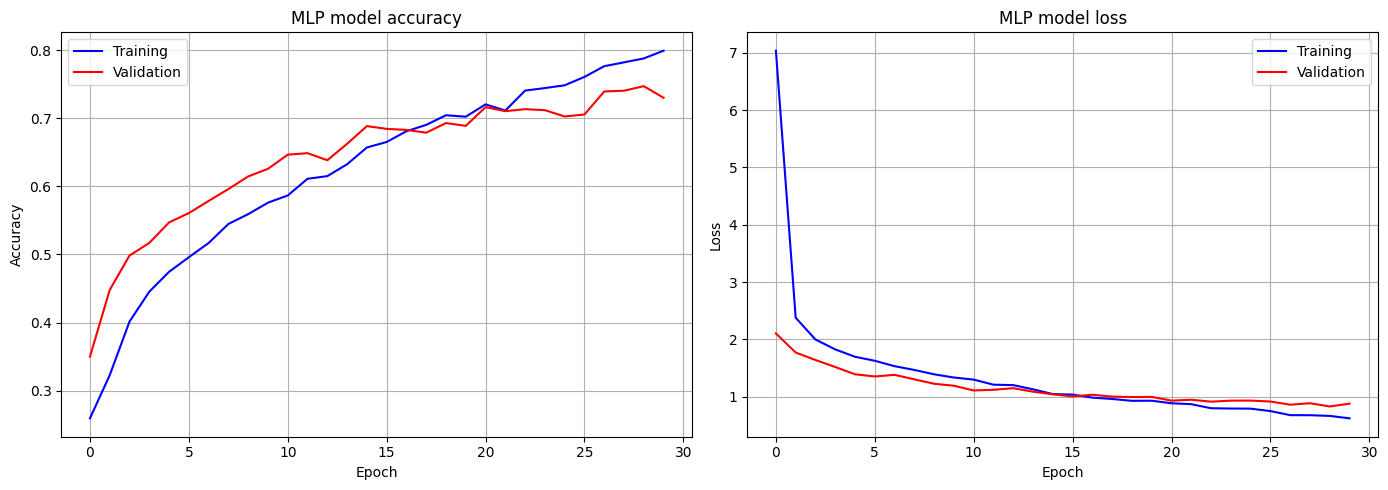

In [16]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(mlp_history.history['accuracy'], 'b-', label='Training')
plt.plot(mlp_history.history['val_accuracy'], 'r-', label='Validation')
plt.title('MLP model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mlp_history.history['loss'], 'b-', label='Training')
plt.plot(mlp_history.history['val_loss'], 'r-', label='Validation')
plt.title('MLP model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
y_pred_mlp = np.argmax(mlp_model.predict(X_test_flat), axis=1)

acc_mlp = accuracy_score(y_test, y_pred_mlp) * 100
pre_mlp = precision_score(y_test, y_pred_mlp, average='macro', zero_division=0) * 100
rec_mlp = recall_score(y_test, y_pred_mlp, average='macro', zero_division=0) * 100
f1_mlp = f1_score(y_test, y_pred_mlp, average='macro', zero_division=0) * 100

print("="*50)
print("🔹 ارزیابی مدل MLP")
print("="*50)
print(f"دقت (Accuracy):  {acc_mlp:.2f}%")
print(f"دقت (Precision): {pre_mlp:.2f}%")
print(f"حساسیت (Recall): {rec_mlp:.2f}%")
print(f"F1-Score:        {f1_mlp:.2f}%")

print("\n📋 گزارش کامل (فقط کلاس‌های دارای داده):")

# پیدا کردن کلاس‌هایی که در y_test وجود دارند
unique_labels = np.unique(y_test)
filtered_class_names = [classes[i] for i in unique_labels]

print(classification_report(
    y_test, y_pred_mlp,
    labels=unique_labels,
    target_names=filtered_class_names,
    zero_division=0
))

85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step
🔹 ارزیابی مدل MLP
دقت (Accuracy):  74.69%
دقت (Precision): 76.91%
حساسیت (Recall): 73.53%
F1-Score:        74.19%

📋 گزارش کامل (فقط کلاس‌های دارای داده):
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.73      0.56      0.63       200
                     Pepper__bell___healthy       0.84      0.82      0.83       200
                      Potato___Early_blight       0.85      0.93      0.89       200
                       Potato___Late_blight       0.62      0.76      0.68       200
                           Potato___healthy       0.81      0.43      0.57        30
                      Tomato_Bacterial_spot       0.73      0.81      0.77       200
                        Tomato_Early_blight       0.50      0.76      0.60       200
                         Tomato_Late_blight       0.80      0.48      0.60       200
                           Tomato_Leaf_

📊 مقایسه نهایی دو مدل
CNN  | دقت: 91.09% | F1: 90.73%
MLP  | دقت: 74.69% | F1: 74.19%
تفاوت: CNN 16.40% بهتر از MLP


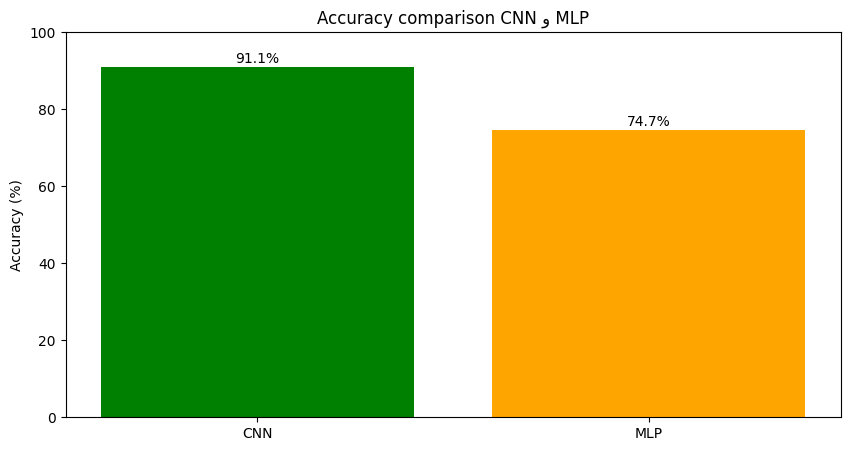

In [18]:
print("="*50)
print("📊 مقایسه نهایی دو مدل")
print("="*50)
print(f"CNN  | دقت: {acc_cnn:.2f}% | F1: {f1_cnn:.2f}%")
print(f"MLP  | دقت: {acc_mlp:.2f}% | F1: {f1_mlp:.2f}%")
print(f"تفاوت: CNN {acc_cnn - acc_mlp:.2f}% بهتر از MLP")

# نمودار مقایسه
plt.figure(figsize=(10, 5))
models = ['CNN', 'MLP']
accuracies = [acc_cnn, acc_mlp]
colors = ['green', 'orange']

plt.bar(models, accuracies, color=colors)
plt.ylabel('Accuracy (%)')
plt.title('Accuracy comparison CNN و MLP')
plt.ylim(0, 100)
for i, v in enumerate(accuracies):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')
plt.show()

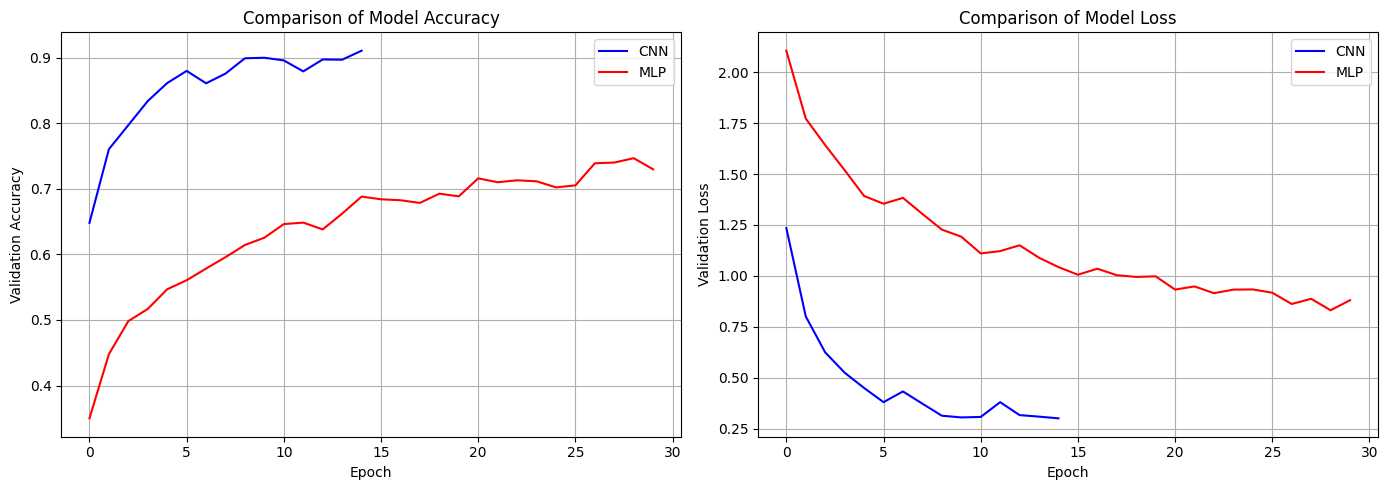

In [19]:
plt.figure(figsize=(14, 5))

# نمودار دقت
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['val_accuracy'], 'b-', label='CNN')
plt.plot(mlp_history.history['val_accuracy'], 'r-', label='MLP')
plt.title('Comparison of Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)

# نمودار loss
plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['val_loss'], 'b-', label='CNN')
plt.plot(mlp_history.history['val_loss'], 'r-', label='MLP')
plt.title('Comparison of Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
with open('classes.json', 'w') as f:
    json.dump(classes, f)

print("✅ کلاس‌ها ذخیره شد: classes.json")

✅ کلاس‌ها ذخیره شد: classes.json


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step


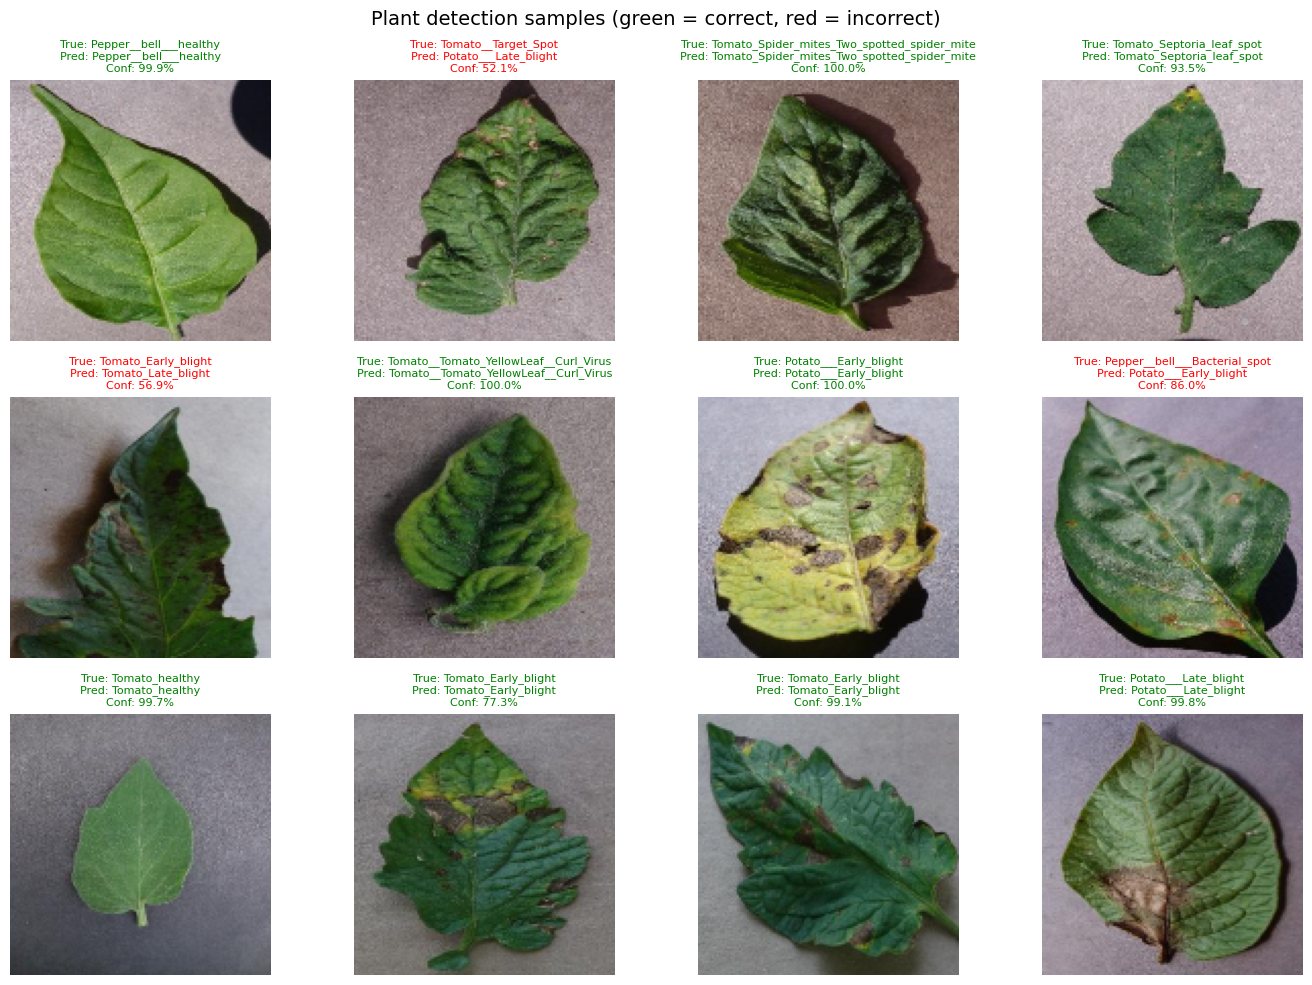

In [21]:
num_images = 12
rows = 3
cols = 4

plt.figure(figsize=(14, 10))

for i in range(num_images):
    idx = random.randint(0, len(X_test) - 1)
    img = X_test[idx]
    true_label = classes[y_test[idx]]
    pred_label = classes[y_pred_cnn[idx]]
    confidence = np.max(cnn_model.predict(img[np.newaxis, ...])) * 100
    
    color = 'green' if true_label == pred_label else 'red'
    
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.1f}%", 
              fontsize=8, color=color)

plt.suptitle('Plant detection samples (green = correct, red = incorrect)', fontsize=14)
plt.tight_layout()
plt.show()

In [22]:
print("="*60)
print("🎉 پروژه تشخیص گیاه با هوش مصنوعی با موفقیت کامل شد!")
print("="*60)
print(f"\n📊 نتایج نهایی:")
print(f"   • CNN  | دقت: {acc_cnn:.2f}%")
print(f"   • MLP  | دقت: {acc_mlp:.2f}%")
print(f"   • مدل برتر: CNN با {acc_cnn - acc_mlp:.2f}% بهبود")
print(f"\n💾 فایل‌های خروجی:")
print(f"   • plant_cnn_model.h5")
print(f"   • classes.json")
print(f"\n🌐 اجرای رابط گرافیکی:")
print(f"   streamlit run app.py")
print("="*60)

🎉 پروژه تشخیص گیاه با هوش مصنوعی با موفقیت کامل شد!

📊 نتایج نهایی:
   • CNN  | دقت: 91.09%
   • MLP  | دقت: 74.69%
   • مدل برتر: CNN با 16.40% بهبود

💾 فایل‌های خروجی:
   • plant_cnn_model.h5
   • classes.json

🌐 اجرای رابط گرافیکی:
   streamlit run app.py
